## Machine Learning Capstone — Classification Track

**Course:** 23CSE301 Machine Learning
**Dataset:** BCI Competition IV — Dataset 2a (EEG Motor Imagery) — https://www.bbci.de/competition/iv/
**Track:** Classification (Part A — Review 1)

---

# 1. Dataset Loading & Audit
## 1.1 Imports & Configuration

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.decoding import CSP
from mne.time_frequency import tfr_morlet
from scipy.signal import welch
from scipy.io import loadmat

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (8, 5)
mne.set_log_level("WARNING")

# ---- Dataset configuration (BCI Competition IV, Dataset 2a) ---------------
DATA_DIR = "data/"                     # put A01T.gdf, A01E.gdf, A02T.gdf, ... here
SFREQ = 250.0
CLASS_NAMES = ["left_hand", "right_hand", "feet", "tongue"]

# Standard BCI IV 2a 22-channel EEG montage + 3 EOG channels
EEG_CHANNELS = ["Fz", "FC3", "FC1", "FCz", "FC2", "FC4", "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
                "CP3", "CP1", "CPz", "CP2", "CP4", "P1", "Pz", "P2", "POz"]
EOG_CHANNELS = ["EOG-left", "EOG-central", "EOG-right"]

# Raw GDF cue-event codes -> class names (BCI IV 2a standard: 769-772).
# IMPORTANT: verify this against YOUR files — run the diagnostic cell in 1.4
# (prints raw.annotations.description) and adjust if your GDF encodes different codes.
EVENT_CODE_MAP = {"769": "left_hand", "770": "right_hand", "771": "feet", "772": "tongue"}

TMIN, TMAX = 0.5, 3.5   # seconds relative to cue onset, motor-imagery window
print("Configuration set.")

Configuration set.


## 1.2 Subject File Discovery (`A0xT.gdf` / `A0xE.gdf` pairs)

In [2]:
def find_subject_pairs(data_dir):
    """Finds subjects with BOTH a training (A0xT.gdf) and evaluation (A0xE.gdf) file."""
    pairs = []
    if os.path.isdir(data_dir):
        train_files = sorted(glob.glob(os.path.join(data_dir, "A??T.gdf")))
        for tf in train_files:
            sub_id = os.path.basename(tf)[:3]           # e.g. "A01"
            ef = os.path.join(data_dir, f"{sub_id}E.gdf")
            if os.path.exists(ef):
                pairs.append({"id": sub_id, "train_file": tf, "test_file": ef})
    return pairs

real_subjects = find_subject_pairs(DATA_DIR)
print(f"Found {len(real_subjects)} real subject(s) with matched T/E files in '{DATA_DIR}'.")

if real_subjects:
    SUBJECT_LIST = [{"id": s["id"], "kind": "real", "info": s} for s in real_subjects]
    print([s["id"] for s in SUBJECT_LIST])
else:
    # No real GDF files present in this environment -> synthetic stand-in so the
    # notebook still runs end-to-end. Replace 'data/' with real A0xT.gdf/A0xE.gdf
    # files and rerun to get real results.
    SUBJECT_LIST = [{"id": f"SIM{i:02d}", "kind": "synthetic", "seed": i * 10} for i in range(1, 4)]
    print("No real files found — using synthetic multi-subject EEG data as a placeholder:")
    print([s["id"] for s in SUBJECT_LIST])

Found 0 real subject(s) with matched T/E files in 'data/'.
No real files found — using synthetic multi-subject EEG data as a placeholder:
['SIM01', 'SIM02', 'SIM03']


In [3]:
def make_synthetic_raw(seed, n_trials_per_class=18, sfreq=SFREQ):
    """Generates a synthetic multi-channel raw EEG recording with realistic structure
    (background noise, eye-blink artifacts, class-specific mu-band bursts at
    class-relevant channels) purely so the full preprocessing/CSP/plotting pipeline
    below is exercised end-to-end without real data present. NOT a substitute for
    real BCI IV 2a results."""
    rng = np.random.default_rng(seed)
    ch_names = EEG_CHANNELS + EOG_CHANNELS
    ch_types = ["eeg"] * len(EEG_CHANNELS) + ["eog"] * len(EOG_CHANNELS)
    info = mne.create_info(ch_names, sfreq, ch_types)

    trial_len = 7.0
    n_trials = n_trials_per_class * 4
    total_dur = n_trials * trial_len + 5
    n_samples = int(total_dur * sfreq)

    data = rng.normal(0, 1.0, size=(len(ch_names), n_samples)) * 5e-6  # background noise (volts)

    labels_order = np.repeat(CLASS_NAMES, n_trials_per_class)
    rng.shuffle(labels_order)

    class_channel_map = {"left_hand": "C4", "right_hand": "C3", "feet": "Cz", "tongue": "CPz"}
    onsets, descriptions = [], []
    t_cursor = 2.0
    for lbl in labels_order:
        onsets.append(t_cursor)
        descriptions.append(lbl)
        ch_idx = ch_names.index(class_channel_map[lbl])
        b_start = int((t_cursor + 0.5) * sfreq)
        b_len = int(3.0 * sfreq)
        t = np.arange(b_len) / sfreq
        burst = 15e-6 * np.sin(2 * np.pi * 10 * t) * np.hanning(b_len)
        data[ch_idx, b_start:b_start + b_len] += burst
        t_cursor += trial_len

    # Simulated eye-blink artifacts (to be cleaned up by ICA in 1.3)
    for _ in range(int(total_dur / 8)):
        b_start = int(rng.uniform(0, total_dur - 1) * sfreq)
        b_len = int(0.3 * sfreq)
        blink = 80e-6 * np.hanning(b_len)
        for ch in EOG_CHANNELS + ["Fz"]:
            idx = ch_names.index(ch)
            end = min(b_start + b_len, n_samples)
            data[idx, b_start:end] += blink[:end - b_start]

    raw = mne.io.RawArray(data, info, verbose=False)
    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing="ignore")
    ann = mne.Annotations(onset=onsets, duration=np.zeros(len(onsets)), description=descriptions)
    raw.set_annotations(ann)
    return raw

print("Synthetic raw generator ready.")

Synthetic raw generator ready.


## 1.3 Raw Signal Preprocessing (Filtering, CAR Spatial Filter, ICA)

In [4]:
def preprocess_raw(raw):
    """
    1) Band-pass filter (4-38 Hz) to keep mu/beta motor-imagery activity and drop drift/noise.
    2) Notch filter at 50 Hz to remove line noise.
    3) Common Average Reference (CAR) — a spatial filter that re-references every channel
       to the average of all channels, reducing common noise sources.
    4) ICA to identify and remove ocular (eye-blink) artifact components using the EOG
       channels as reference.
    """
    raw = raw.copy()
    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing="ignore")

    raw.filter(l_freq=4.0, h_freq=38.0, fir_design="firwin", picks="eeg", verbose=False)
    try:
        raw.notch_filter(freqs=50.0, picks="eeg", verbose=False)
    except Exception:
        pass

    raw.set_eeg_reference("average", projection=False, verbose=False)  # spatial filter (CAR)

    ica = mne.preprocessing.ICA(n_components=15, random_state=RANDOM_STATE, max_iter=200)
    ica.fit(raw, picks="eeg", verbose=False)

    eog_present = [ch for ch in EOG_CHANNELS if ch in raw.ch_names]
    if eog_present:
        try:
            eog_indices, _ = ica.find_bads_eog(raw, ch_name=eog_present, verbose=False)
            ica.exclude = eog_indices
        except Exception:
            ica.exclude = []
    ica.apply(raw, verbose=False)
    return raw

print("Preprocessing function ready (band-pass + notch filter, CAR, ICA).")

Preprocessing function ready (band-pass + notch filter, CAR, ICA).


## 1.4 Epoching & Event/Label Extraction (train = `A0xT.gdf`, test = `A0xE.gdf`)

In [5]:
def annotations_to_class_labels(raw):
    """Keeps only cue annotations and renames them to class names, handling either
    raw numeric GDF cue codes (real data) or already-named annotations (synthetic data)."""
    ann = raw.annotations
    desc = np.array(ann.description)

    mask_named = np.isin(desc, CLASS_NAMES)
    if mask_named.sum() > 0:
        return ann[mask_named]

    mask_coded = np.isin(desc, list(EVENT_CODE_MAP.keys()))
    if mask_coded.sum() > 0:
        kept = ann[mask_coded]
        kept.description = np.array([EVENT_CODE_MAP[d] for d in kept.description])
        return kept

    return ann[np.zeros(len(desc), dtype=bool)]  # nothing matched


def load_true_labels_for_eval(subject_id, data_dir):
    """Some BCI IV 2a distributions ship A0xE.gdf with cue code 783 ('unknown') and provide
    the real evaluation labels separately (e.g. true_labels/A0xE.mat with a 'classlabel'
    array, 1-indexed). Checks common locations; returns None if not found (falls back to
    whatever is embedded in the GDF annotations)."""
    candidates = [
        os.path.join(data_dir, "true_labels", f"{subject_id}E.mat"),
        os.path.join(data_dir, f"{subject_id}E.mat"),
    ]
    for c in candidates:
        if os.path.exists(c):
            mat = loadmat(c)
            if "classlabel" in mat:
                idx = np.array(mat["classlabel"]).ravel().astype(int) - 1  # 1-indexed -> 0-indexed
                return np.array([CLASS_NAMES[i] for i in idx])
    return None


def make_epochs(raw, subject_id=None, data_dir=DATA_DIR, is_eval=False):
    kept_ann = annotations_to_class_labels(raw)
    raw = raw.copy().set_annotations(kept_ann)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, event_id=event_id, tmin=TMIN, tmax=TMAX,
                         baseline=None, preload=True, picks="eeg", verbose=False)
    inv_event_id = {v: k for k, v in event_id.items()}
    y = np.array([inv_event_id[e] for e in epochs.events[:, -1]])

    if is_eval and subject_id is not None:
        true_labels = load_true_labels_for_eval(subject_id, data_dir)
        if true_labels is not None and len(true_labels) == len(y):
            y = true_labels  # override with the real evaluation-session labels

    return epochs, y


print("Epoching functions ready.")

Epoching functions ready.


In [6]:
subject_data = {}

for s in SUBJECT_LIST:
    if s["kind"] == "real":
        raw_train = mne.io.read_raw_gdf(s["info"]["train_file"], preload=True, verbose=False)
        raw_test = mne.io.read_raw_gdf(s["info"]["test_file"], preload=True, verbose=False)
    else:
        raw_train = make_synthetic_raw(s["seed"])
        raw_test = make_synthetic_raw(s["seed"] + 100)

    raw_train = preprocess_raw(raw_train)
    raw_test = preprocess_raw(raw_test)

    epochs_train, y_train_lbl = make_epochs(raw_train, subject_id=s["id"], is_eval=False)
    epochs_test, y_test_lbl = make_epochs(raw_test, subject_id=s["id"], is_eval=True)

    subject_data[s["id"]] = dict(
        epochs_train=epochs_train, y_train=y_train_lbl,
        epochs_test=epochs_test, y_test=y_test_lbl,
    )
    print(f"[{s['id']}] train (A0xT): {len(epochs_train)} epochs | "
          f"test (A0xE): {len(epochs_test)} epochs")

DATA_SOURCE = SUBJECT_LIST[0]["kind"]
print(f"\nData source: {DATA_SOURCE}")

[SIM01] train (A0xT): 72 epochs | test (A0xE): 72 epochs


[SIM02] train (A0xT): 72 epochs | test (A0xE): 72 epochs


[SIM03] train (A0xT): 72 epochs | test (A0xE): 72 epochs

Data source: synthetic


## 1.5 Dataset Audit: Sampling Rate, Channels, Per-Class Trial Counts (Train vs Test)

In [7]:
first_id = SUBJECT_LIST[0]["id"]
first_epochs = subject_data[first_id]["epochs_train"]

print(f"Sampling rate: {first_epochs.info['sfreq']} Hz")
print(f"Number of EEG channels: {len(first_epochs.ch_names)}")
print(f"Channel names: {first_epochs.ch_names}")
print(f"Epoch time window: {TMIN}s to {TMAX}s relative to cue onset")
print()

audit_rows = []
for sid, d in subject_data.items():
    train_counts = pd.Series(d["y_train"]).value_counts().reindex(CLASS_NAMES, fill_value=0)
    test_counts = pd.Series(d["y_test"]).value_counts().reindex(CLASS_NAMES, fill_value=0)
    row = {"subject": sid, "n_train": len(d["y_train"]), "n_test": len(d["y_test"])}
    for c in CLASS_NAMES:
        row[f"train_{c}"] = train_counts[c]
        row[f"test_{c}"] = test_counts[c]
    audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)
audit_df

Sampling rate: 250.0 Hz
Number of EEG channels: 22
Channel names: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
Epoch time window: 0.5s to 3.5s relative to cue onset



,subject,n_train,n_test,train_left_hand,test_left_hand,train_right_hand,test_right_hand,train_feet,test_feet,train_tongue,test_tongue
0,SIM01,72,72,18,18,18,18,18,18,18,18
1,SIM02,72,72,18,18,18,18,18,18,18,18
2,SIM03,72,72,18,18,18,18,18,18,18,18


In [8]:
# Missing-value check on the raw epoch arrays (should be none for clean EEG data)
n_missing = sum(np.isnan(d["epochs_train"].get_data()).sum() + np.isnan(d["epochs_test"].get_data()).sum()
                for d in subject_data.values())
print(f"Total NaN values across all subjects' epoch data: {n_missing}")

Total NaN values across all subjects' epoch data: 0


---

# 2. Domain-Specific EEG Visualizations
## 2.1 Power Spectral Density (PSD) per Class

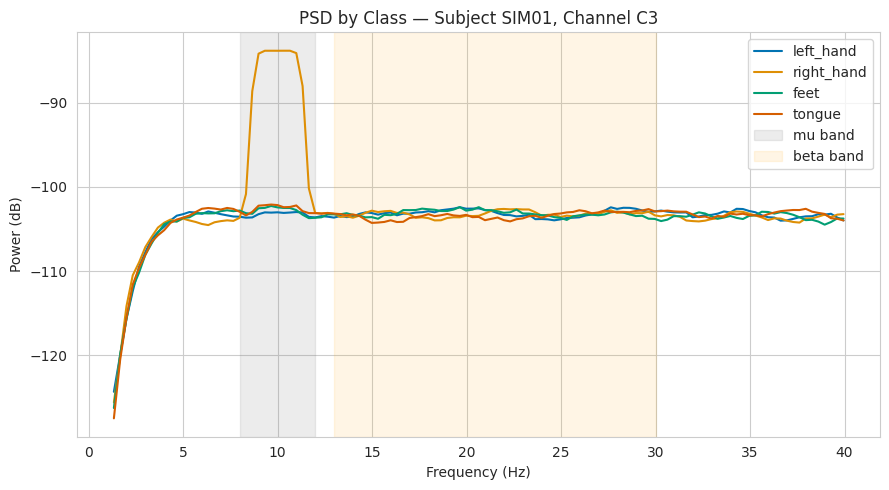

In [9]:
ref_epochs = subject_data[first_id]["epochs_train"]
ref_y = subject_data[first_id]["y_train"]
plot_channel = "C3" if "C3" in ref_epochs.ch_names else ref_epochs.ch_names[0]
ch_idx = ref_epochs.ch_names.index(plot_channel)

fig, ax = plt.subplots(figsize=(9, 5))
for cls in CLASS_NAMES:
    cls_epochs = ref_epochs[ref_y == cls] if (ref_y == cls).any() else None
    if cls_epochs is None or len(cls_epochs) == 0:
        continue
    psd = cls_epochs.compute_psd(fmin=1, fmax=40, picks=[plot_channel], verbose=False)
    freqs = psd.freqs
    power = psd.get_data().mean(axis=(0, 1))
    ax.plot(freqs, 10 * np.log10(power + 1e-20), label=cls)

ax.axvspan(8, 12, color="grey", alpha=0.15, label="mu band")
ax.axvspan(13, 30, color="orange", alpha=0.10, label="beta band")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (dB)")
ax.set_title(f"PSD by Class — Subject {first_id}, Channel {plot_channel}")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Time-Frequency (ERD/ERS) Analysis

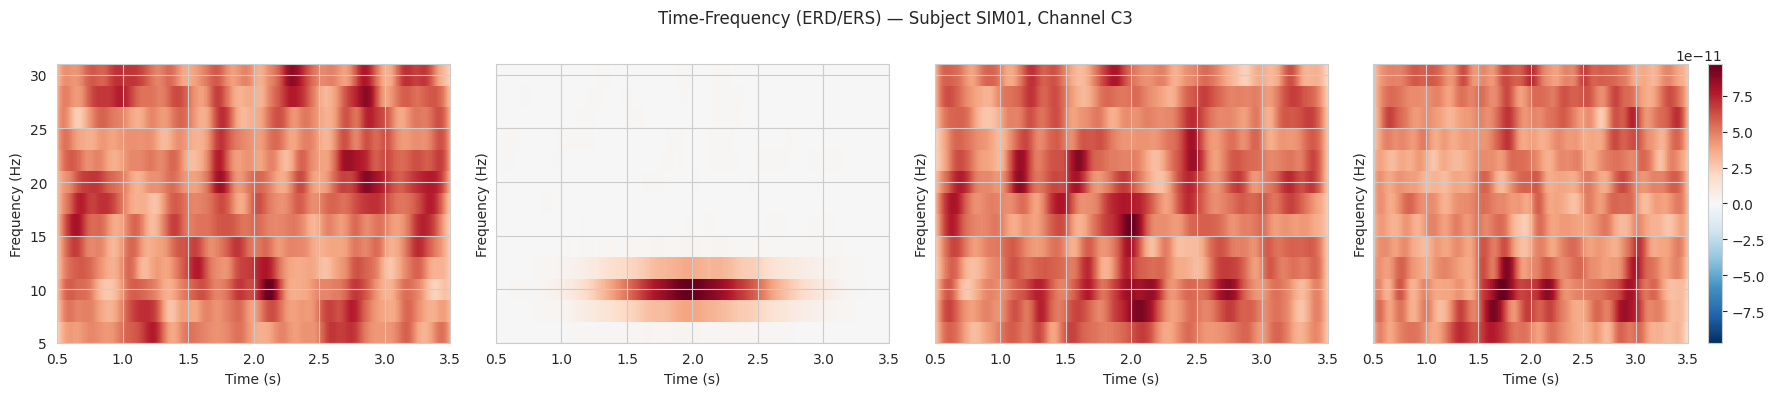

In [10]:
freqs = np.arange(6, 32, 2)
n_cycles = freqs / 2.0

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 4), sharey=True)
for ax, cls in zip(axes, CLASS_NAMES):
    if not (ref_y == cls).any():
        ax.axis("off")
        continue
    cls_epochs = ref_epochs[ref_y == cls]
    power = tfr_morlet(cls_epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False,
                        picks=[plot_channel], average=True, verbose=False)
    power.plot([0], baseline=None, mode="mean", axes=ax, colorbar=(cls == CLASS_NAMES[-1]),
                show=False, title=cls)
fig.suptitle(f"Time-Frequency (ERD/ERS) — Subject {first_id}, Channel {plot_channel}")
plt.tight_layout()
plt.show()

## 2.3 Topographic Map of CSP Spatial Patterns

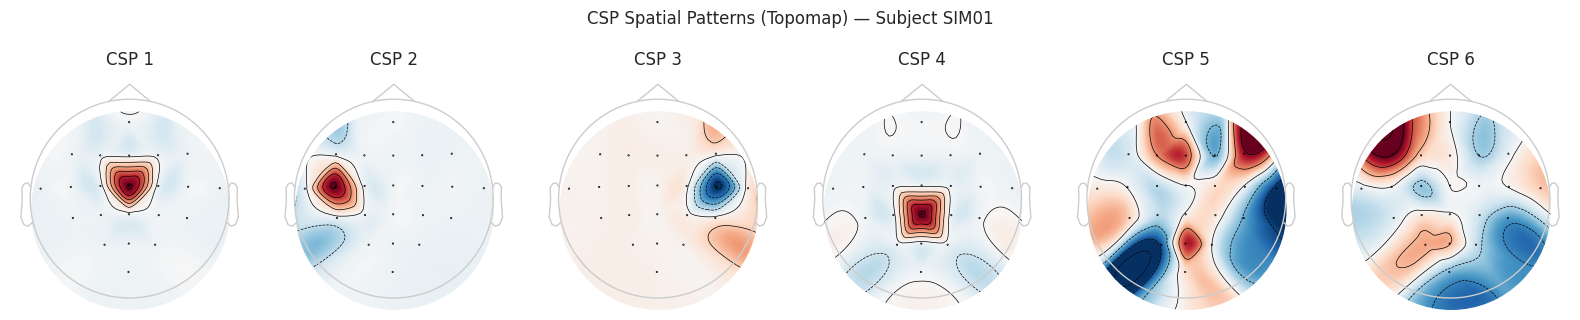

In [11]:
le_ref = LabelEncoder().fit(CLASS_NAMES)
y_ref_enc = le_ref.transform(ref_y)

csp_viz = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)
csp_viz.fit(ref_epochs.get_data(), y_ref_enc)

# Plot the CSP spatial patterns (columns of the inverse filter matrix) directly as topomaps —
# built manually with plot_topomap since CSP.plot_patterns() can be unreliable for the
# multi-class (>2 class) case used here.
patterns = csp_viz.patterns_[:6]  # shape: (n_components, n_channels)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    mne.viz.plot_topomap(patterns[i], ref_epochs.info, axes=ax, show=False, sphere="auto")
    ax.set_title(f"CSP {i+1}")
fig.suptitle(f"CSP Spatial Patterns (Topomap) — Subject {first_id}", y=1.05)
plt.tight_layout()
plt.show()

---

# 3. Feature Extraction — Common Spatial Patterns (CSP) + Band Power
## 3.1 CSP Spatial Filtering (fit on training session only, per subject)

In [12]:
N_CSP = 6
BANDS = {"mu": (8, 12), "beta": (13, 30)}

def band_power_features(epochs_data, sfreq, bands=BANDS):
    n_epochs, n_channels, n_times = epochs_data.shape
    rows = []
    for ep in range(n_epochs):
        row = {}
        for ch in range(n_channels):
            f, psd = welch(epochs_data[ep, ch, :], fs=sfreq, nperseg=min(256, n_times))
            for band_name, (lo, hi) in bands.items():
                mask = (f >= lo) & (f <= hi)
                row[f"ch{ch+1}_{band_name}"] = np.trapezoid(psd[mask], f[mask]) if mask.any() else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def extract_features(subject_dict, n_csp=N_CSP):
    """Fits CSP on the TRAINING session only (A0xT), then transforms both the training
    and evaluation (A0xE) sessions with those same filters — no leakage from test to train.
    Combines CSP log-variance features with band-power features."""
    epochs_train, y_train = subject_dict["epochs_train"], subject_dict["y_train"]
    epochs_test, y_test = subject_dict["epochs_test"], subject_dict["y_test"]

    y_train_enc = le_ref.transform(y_train)

    csp = CSP(n_components=n_csp, reg="ledoit_wolf", log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(epochs_train.get_data(), y_train_enc)
    X_test_csp = csp.transform(epochs_test.get_data())

    bp_train = band_power_features(epochs_train.get_data(), SFREQ)
    bp_test = band_power_features(epochs_test.get_data(), SFREQ)

    csp_cols = [f"csp_{i+1}" for i in range(n_csp)]
    X_train_df = pd.concat([pd.DataFrame(X_train_csp, columns=csp_cols), bp_train], axis=1)
    X_test_df = pd.concat([pd.DataFrame(X_test_csp, columns=csp_cols), bp_test], axis=1)

    X_train_df["target"] = y_train
    X_test_df["target"] = y_test
    return X_train_df, X_test_df, csp


subject_features = {}
for sid, d in subject_data.items():
    X_tr, X_te, csp_fitted = extract_features(d)
    subject_features[sid] = {"train": X_tr, "test": X_te, "csp": csp_fitted}
    print(f"[{sid}] feature matrix — train: {X_tr.shape}, test: {X_te.shape}")

[SIM01] feature matrix — train: (72, 51), test: (72, 51)


[SIM02] feature matrix — train: (72, 51), test: (72, 51)


[SIM03] feature matrix — train: (72, 51), test: (72, 51)


## 3.2 Combined Feature Matrix — Pooled Across Subjects (for EDA/reporting)

In [13]:
FEATURE_COLS = [c for c in subject_features[first_id]["train"].columns if c != "target"]

pooled_train_frames = []
for sid, f in subject_features.items():
    tmp = f["train"].copy()
    tmp["subject"] = sid
    pooled_train_frames.append(tmp)
pooled_train_df = pd.concat(pooled_train_frames, ignore_index=True)

print(f"Pooled training-session feature table (all subjects, A0xT only): {pooled_train_df.shape}")
pooled_train_df.head()

Pooled training-session feature table (all subjects, A0xT only): (216, 52)


,csp_1,csp_2,csp_3,csp_4,csp_5,csp_6,ch1_mu,ch1_beta,ch2_mu,ch2_beta,...,ch19_mu,ch19_beta,ch20_mu,ch20_beta,ch21_mu,ch21_beta,ch22_mu,ch22_beta,target,subject
0,-0.924423,1.025874,-0.932193,-0.897390,-0.179580,-0.116275,1.343915e-14,1.018208e-14,7.297795e-13,2.135776e-12,...,1.009236e-12,3.093329e-12,6.867162e-13,2.413152e-12,6.484989e-13,2.519198e-12,4.199217e-13,3.738844e-12,right_hand,SIM01
1,-0.769269,-0.704955,1.005022,-0.799152,-0.029910,-0.098933,3.610981e-14,1.291227e-14,7.500235e-13,2.517388e-12,...,7.468700e-13,2.742181e-12,3.724746e-13,2.606306e-12,8.892453e-13,3.119062e-12,5.598142e-13,2.975645e-12,left_hand,SIM01
2,1.035697,-0.902889,-0.783560,-0.977084,0.053110,0.028438,4.850438e-14,9.661050e-15,4.589420e-13,2.804101e-12,...,2.990524e-13,3.909114e-12,6.121890e-13,3.772977e-12,9.689692e-13,2.059017e-12,5.334157e-13,3.847624e-12,feet,SIM01
3,-0.806963,-0.877035,0.979230,-0.867500,-0.044166,0.060539,3.704721e-14,9.192826e-15,5.659502e-13,3.739701e-12,...,3.327298e-13,2.321217e-12,4.555169e-13,2.260416e-12,8.278216e-13,3.070381e-12,1.000457e-12,3.507108e-12,left_hand,SIM01
4,-0.703817,-0.858508,1.002243,-0.880198,-0.128812,0.048214,3.012226e-14,1.063461e-14,9.768855e-13,3.350485e-12,...,4.736829e-13,3.477023e-12,7.640967e-13,2.801442e-12,6.035167e-13,3.425837e-12,3.069615e-13,3.519105e-12,left_hand,SIM01


---

# 4. Exploratory Data Analysis (EDA) on Extracted Features
## 4.1 Feature Distribution Plots

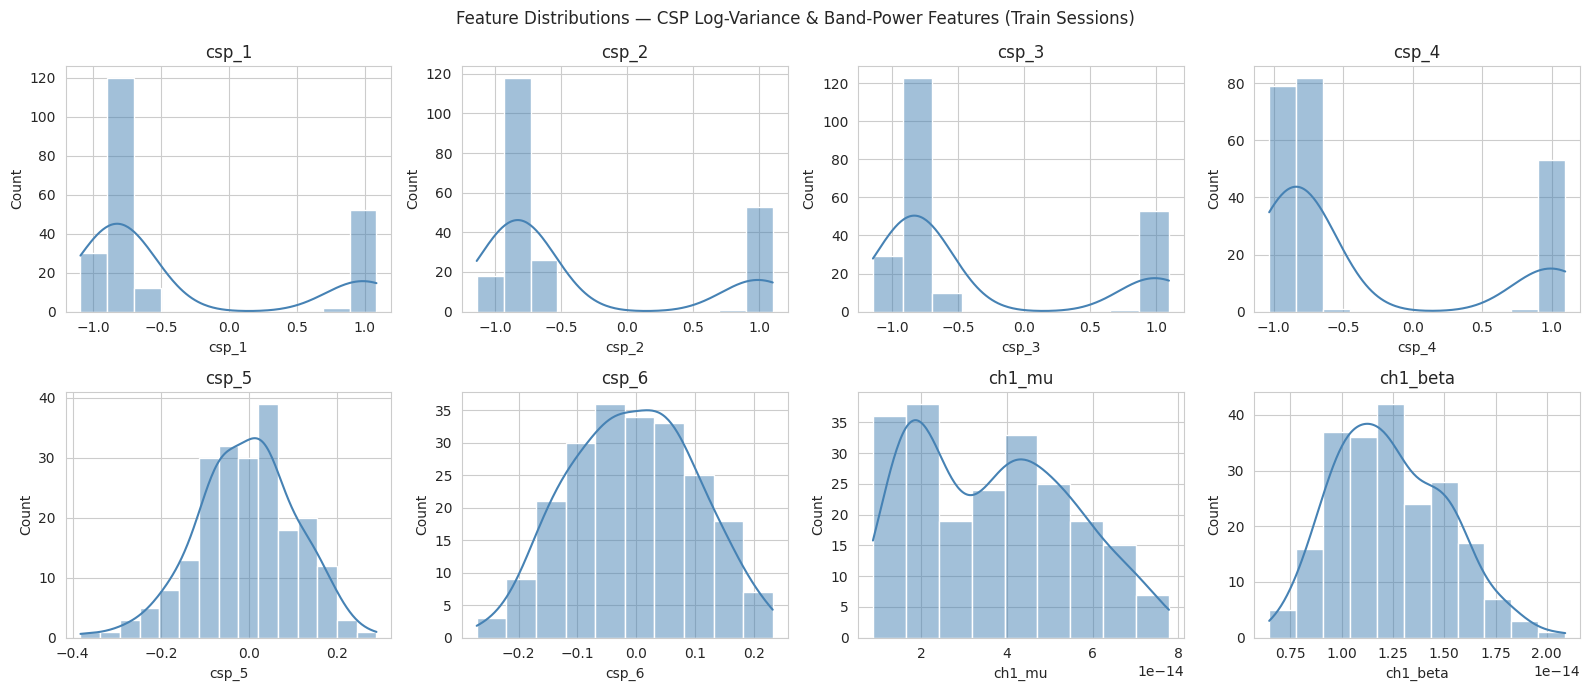

In [14]:
subset = FEATURE_COLS[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, subset):
    sns.histplot(pooled_train_df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
fig.suptitle("Feature Distributions — CSP Log-Variance & Band-Power Features (Train Sessions)")
plt.tight_layout()
plt.show()

## 4.2 Correlation Heatmap

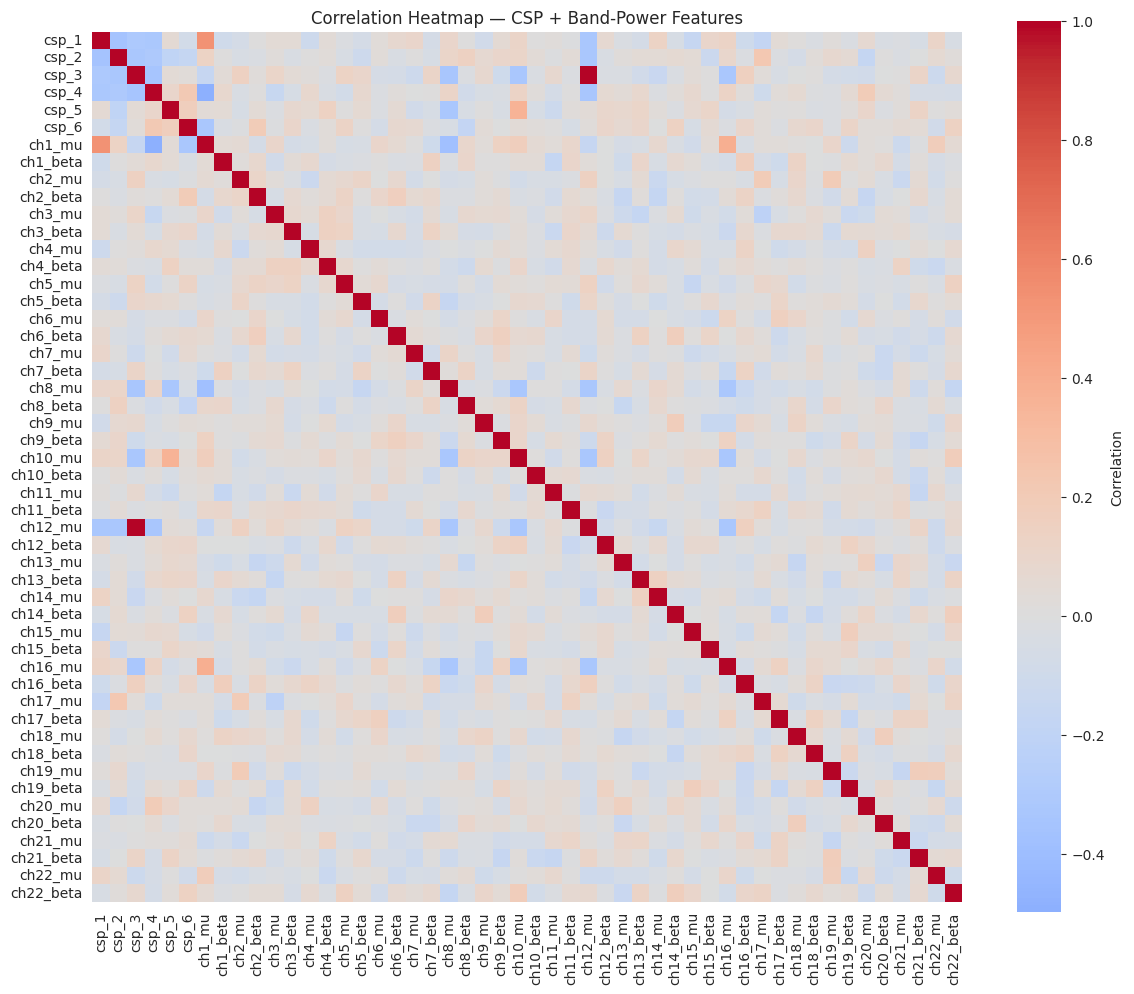

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(pooled_train_df[FEATURE_COLS].corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — CSP + Band-Power Features")
plt.tight_layout()
plt.show()

## 4.3 Target Class Distribution Plot

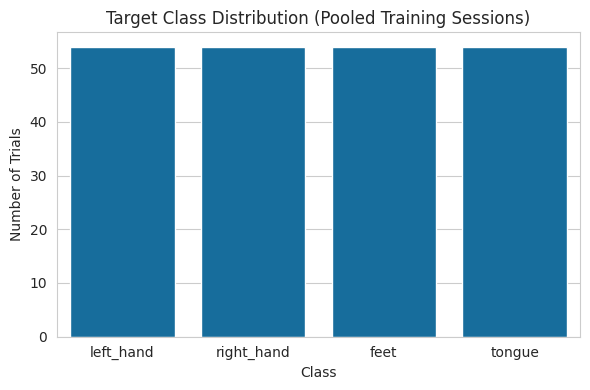

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=pooled_train_df, order=CLASS_NAMES)
plt.title("Target Class Distribution (Pooled Training Sessions)")
plt.xlabel("Class")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

## 4.4 Feature-vs-Target Scatter Plots

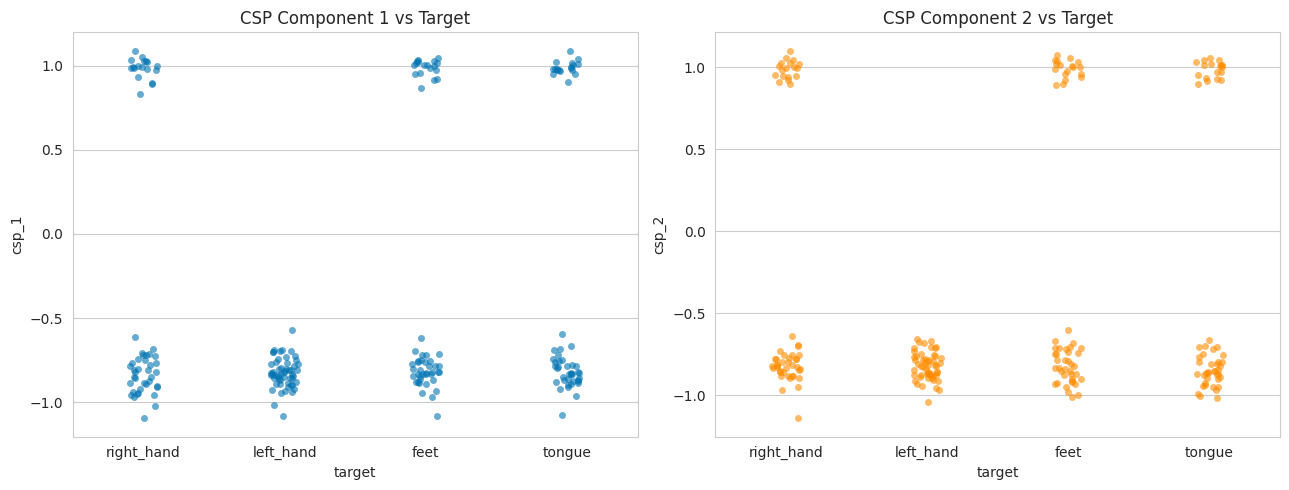

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.stripplot(x="target", y="csp_1", data=pooled_train_df, ax=axes[0], jitter=True, alpha=0.6)
axes[0].set_title("CSP Component 1 vs Target")
sns.stripplot(x="target", y="csp_2", data=pooled_train_df, ax=axes[1], jitter=True, alpha=0.6,
              color="darkorange")
axes[1].set_title("CSP Component 2 vs Target")
plt.tight_layout()
plt.show()

## 4.5 Insight Commentary

- **Feature distributions:** _Note which CSP components show the clearest separation across
  classes vs. band-power features._
- **Correlation heatmap:** _CSP components are designed to be mutually decorrelated (by
  construction), so expect low correlation among `csp_*` columns; band-power features across
  neighbouring channels will likely show higher correlation._
- **Class distribution:** _Confirm the 72-per-class balance from the dataset audit (Section 1.5)
  holds after pooling._
- **Scatter plots:** _Note whether CSP components 1–2 visibly separate the 4 classes — CSP is
  specifically optimised to maximise variance differences between classes, so separation here
  should be much clearer than with raw band power alone._

---

# 5. Data Cleaning
## 5.1 Missing Value Check

In [18]:
missing = pooled_train_df[FEATURE_COLS].isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:" if not missing.empty else "No missing values found.")
if not missing.empty:
    print(missing)

No missing values found.


## 5.2 Duplicate Check & Treatment

In [19]:
n_dupes = pooled_train_df.duplicated(subset=FEATURE_COLS).sum()
print(f"Duplicate feature rows (pooled training data): {n_dupes}")
if n_dupes > 0:
    pooled_train_df = pooled_train_df.drop_duplicates(subset=FEATURE_COLS).reset_index(drop=True)
    print(f"Duplicates removed. New shape: {pooled_train_df.shape}")

Duplicate feature rows (pooled training data): 0


## 5.3 Outlier Detection & Treatment (IQR capping, bounds computed on train only)

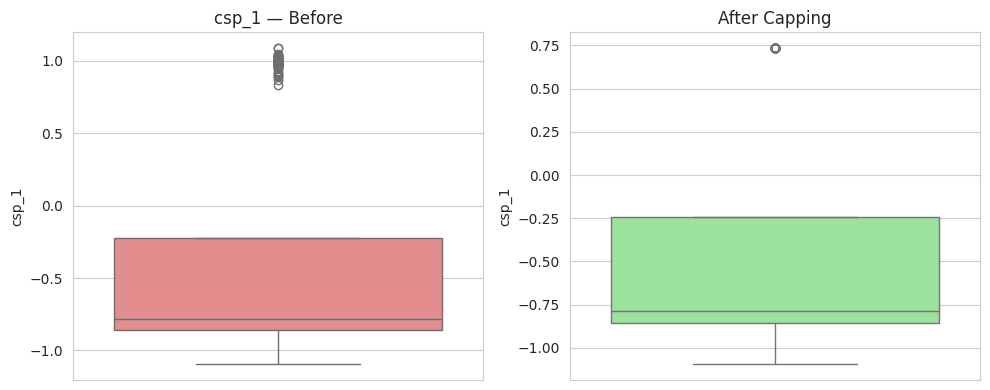

In [20]:
def compute_iqr_bounds(train_df, cols, factor=1.5):
    bounds = {}
    for col in cols:
        q1, q3 = train_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        bounds[col] = (q1 - factor * iqr, q3 + factor * iqr)
    return bounds

def apply_iqr_bounds(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)
    return df

# Bounds are computed on the pooled TRAINING features only, then reused later (Section 6)
# to clip both each subject's train AND test features — this avoids leaking test-set
# statistics into the cleaning step.
global_iqr_bounds = compute_iqr_bounds(pooled_train_df, FEATURE_COLS)

before = pooled_train_df[FEATURE_COLS[0]].copy()
pooled_train_df = apply_iqr_bounds(pooled_train_df, global_iqr_bounds)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=before, ax=axes[0], color="lightcoral"); axes[0].set_title(f"{FEATURE_COLS[0]} — Before")
sns.boxplot(y=pooled_train_df[FEATURE_COLS[0]], ax=axes[1], color="lightgreen"); axes[1].set_title("After Capping")
plt.tight_layout()
plt.show()

---

# 6. Preprocessing & Feature Scaling
## 6.1 Label Encoding

In [21]:
print("Class mapping:")
for cls, code_val in zip(le_ref.classes_, le_ref.transform(le_ref.classes_)):
    print(f"  {cls} -> {code_val}")

Class mapping:
  feet -> 0
  left_hand -> 1
  right_hand -> 2
  tongue -> 3


## 6.2 Feature Scaling (fit on training data only)

## 6.3 Train/Test Definition — `A0xT.gdf` (train) vs `A0xE.gdf` (test)

**Per team review: this is NOT a random `train_test_split`.** For every subject, the classifier
is trained on the *entire* `A0xT.gdf` session and evaluated on the *entire*, separately-recorded
`A0xE.gdf` session — matching the BCI Competition IV protocol and avoiding the leakage that a
random within-session split would introduce.

In [22]:
def prepare_subject_xy(sid):
    """Applies outlier-capping (train-derived bounds) and per-subject scaling
    (fit on that subject's A0xT session only), returning ready-to-model arrays."""
    X_train_df = apply_iqr_bounds(subject_features[sid]["train"], global_iqr_bounds)
    X_test_df = apply_iqr_bounds(subject_features[sid]["test"], global_iqr_bounds)

    y_train = le_ref.transform(X_train_df["target"])
    y_test = le_ref.transform(X_test_df["target"])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df[FEATURE_COLS])   # fit on A0xT only
    X_test_scaled = scaler.transform(X_test_df[FEATURE_COLS])          # transform A0xE

    return X_train_scaled, y_train, X_test_scaled, y_test, scaler

print("Per-subject train(A0xT)/test(A0xE) preparation function ready.")

Per-subject train(A0xT)/test(A0xE) preparation function ready.


---

# 7. Classification Track — Part A: Within-Subject Evaluation
Each of the 5 required Part-A algorithms is trained on each subject's `A0xT` session and
evaluated on that same subject's `A0xE` session; results are then averaged across subjects.

## 7.1 Logistic Regression
## 7.2 K-Nearest Neighbors
## 7.3 Naive Bayes (Gaussian)
## 7.4 Decision Tree Classifier
## 7.5 Support Vector Machine (SVC)

In [23]:
def get_part_a_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=7),
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        "SVM (SVC)": SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE),
    }

within_subject_results = []
within_subject_preds = {name: {"y_true": [], "y_pred": []} for name in get_part_a_models()}

for sid in subject_features:
    X_train, y_train, X_test, y_test, _ = prepare_subject_xy(sid)
    models = get_part_a_models()
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        within_subject_preds[name]["y_true"].extend(y_test.tolist())
        within_subject_preds[name]["y_pred"].extend(y_pred.tolist())

        within_subject_results.append({
            "Subject": sid,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        })

within_df = pd.DataFrame(within_subject_results)
within_df.head(10)

,Subject,Model,Accuracy,F1 (weighted)
0,SIM01,Logistic Regression,1.000000,1.000000
1,SIM01,KNN,0.902778,0.901253
2,SIM01,Naive Bayes,1.000000,1.000000
3,SIM01,Decision Tree,1.000000,1.000000
4,SIM01,SVM (SVC),1.000000,1.000000
5,SIM02,Logistic Regression,1.000000,1.000000
6,SIM02,KNN,0.986111,0.986100
7,SIM02,Naive Bayes,1.000000,1.000000
8,SIM02,Decision Tree,1.000000,1.000000
9,SIM02,SVM (SVC),1.000000,1.000000


## 7.6 Within-Subject Results — Averaged Across Subjects

In [24]:
within_summary = (within_df.groupby("Model")[["Accuracy", "F1 (weighted)"]]
                   .agg(["mean", "std"]).round(3))
within_summary.columns = ["_".join(c) for c in within_summary.columns]
within_summary = within_summary.sort_values("F1 (weighted)_mean", ascending=False)
within_summary

,Accuracy_mean,Accuracy_std,F1 (weighted)_mean,F1 (weighted)_std
Model,,,,
Logistic Regression,1.000,0.000,1.000,0.000
SVM (SVC),1.000,0.000,1.000,0.000
Naive Bayes,1.000,0.000,1.000,0.000
KNN,0.944,0.042,0.943,0.042
Decision Tree,0.755,0.425,0.717,0.490


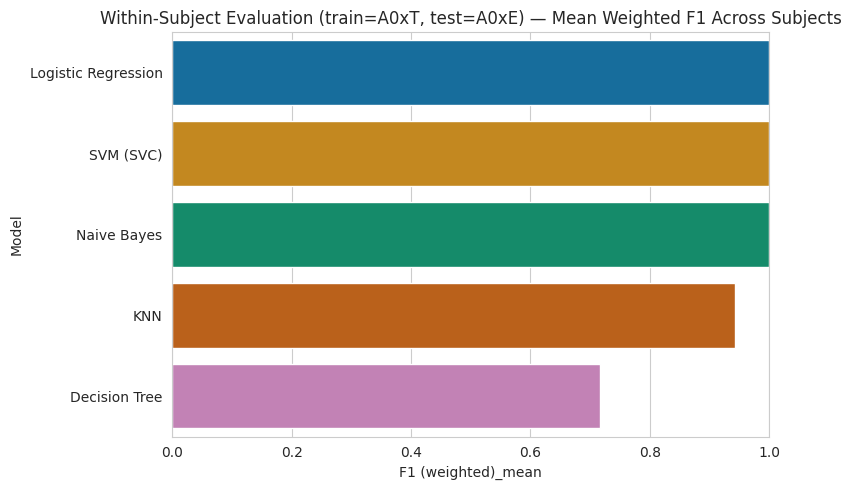

In [25]:
plt.figure(figsize=(8, 5))
plot_df = within_summary.reset_index()
sns.barplot(x="F1 (weighted)_mean", y="Model", data=plot_df, palette="colorblind")
plt.title("Within-Subject Evaluation (train=A0xT, test=A0xE) — Mean Weighted F1 Across Subjects")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---

# 8. Cross-Subject Evaluation (Leave-One-Subject-Out)

Within-subject accuracy (Section 7) measures how well a model works for a subject it has already
seen data from. **Cross-subject accuracy** measures generalisation to a *completely unseen*
subject — a much harder and more realistic test for a deployable BCI system. We use
**Leave-One-Subject-Out (LOSO)**: for each subject held out in turn, the model trains on every
other subject's pooled data (train + test sessions) and is tested on the held-out subject's full
data (train + test sessions).

## 8.1 LOSO Pipeline

In [26]:
def get_all_subject_features(sid):
    X_df = pd.concat([subject_features[sid]["train"], subject_features[sid]["test"]], ignore_index=True)
    X_df = apply_iqr_bounds(X_df, global_iqr_bounds)
    y = le_ref.transform(X_df["target"])
    return X_df[FEATURE_COLS].values, y

cross_subject_results = []
subject_ids = list(subject_features.keys())

for held_out in subject_ids:
    X_pool, y_pool = [], []
    for sid in subject_ids:
        if sid == held_out:
            continue
        X_s, y_s = get_all_subject_features(sid)
        X_pool.append(X_s)
        y_pool.append(y_s)
    X_pool = np.vstack(X_pool)
    y_pool = np.concatenate(y_pool)

    X_held, y_held = get_all_subject_features(held_out)

    scaler = StandardScaler()
    X_pool_scaled = scaler.fit_transform(X_pool)     # fit on the OTHER subjects only
    X_held_scaled = scaler.transform(X_held)          # transform the held-out subject

    models = get_part_a_models()
    for name, model in models.items():
        model.fit(X_pool_scaled, y_pool)
        y_pred = model.predict(X_held_scaled)
        cross_subject_results.append({
            "Held-out subject": held_out,
            "Model": name,
            "Accuracy": accuracy_score(y_held, y_pred),
            "F1 (weighted)": f1_score(y_held, y_pred, average="weighted", zero_division=0),
        })

cross_df = pd.DataFrame(cross_subject_results)
cross_df.head(10)

,Held-out subject,Model,Accuracy,F1 (weighted)
0,SIM01,Logistic Regression,1.000000,1.000000
1,SIM01,KNN,0.694444,0.684023
2,SIM01,Naive Bayes,1.000000,1.000000
3,SIM01,Decision Tree,1.000000,1.000000
4,SIM01,SVM (SVC),1.000000,1.000000
5,SIM02,Logistic Regression,1.000000,1.000000
6,SIM02,KNN,0.708333,0.709610
7,SIM02,Naive Bayes,1.000000,1.000000
8,SIM02,Decision Tree,1.000000,1.000000
9,SIM02,SVM (SVC),1.000000,1.000000


## 8.2 Cross-Subject Comparison Table

In [27]:
cross_summary = (cross_df.groupby("Model")[["Accuracy", "F1 (weighted)"]]
                  .agg(["mean", "std"]).round(3))
cross_summary.columns = ["_".join(c) for c in cross_summary.columns]
cross_summary = cross_summary.sort_values("F1 (weighted)_mean", ascending=False)
cross_summary

,Accuracy_mean,Accuracy_std,F1 (weighted)_mean,F1 (weighted)_std
Model,,,,
Decision Tree,1.00,0.000,1.000,0.000
Logistic Regression,1.00,0.000,1.000,0.000
Naive Bayes,1.00,0.000,1.000,0.000
SVM (SVC),1.00,0.000,1.000,0.000
KNN,0.69,0.021,0.684,0.025


---

# 9. Part A — Consolidated Model Evaluation
## 9.1 Confusion Matrices (Within-Subject, Pooled Predictions Across All Subjects)

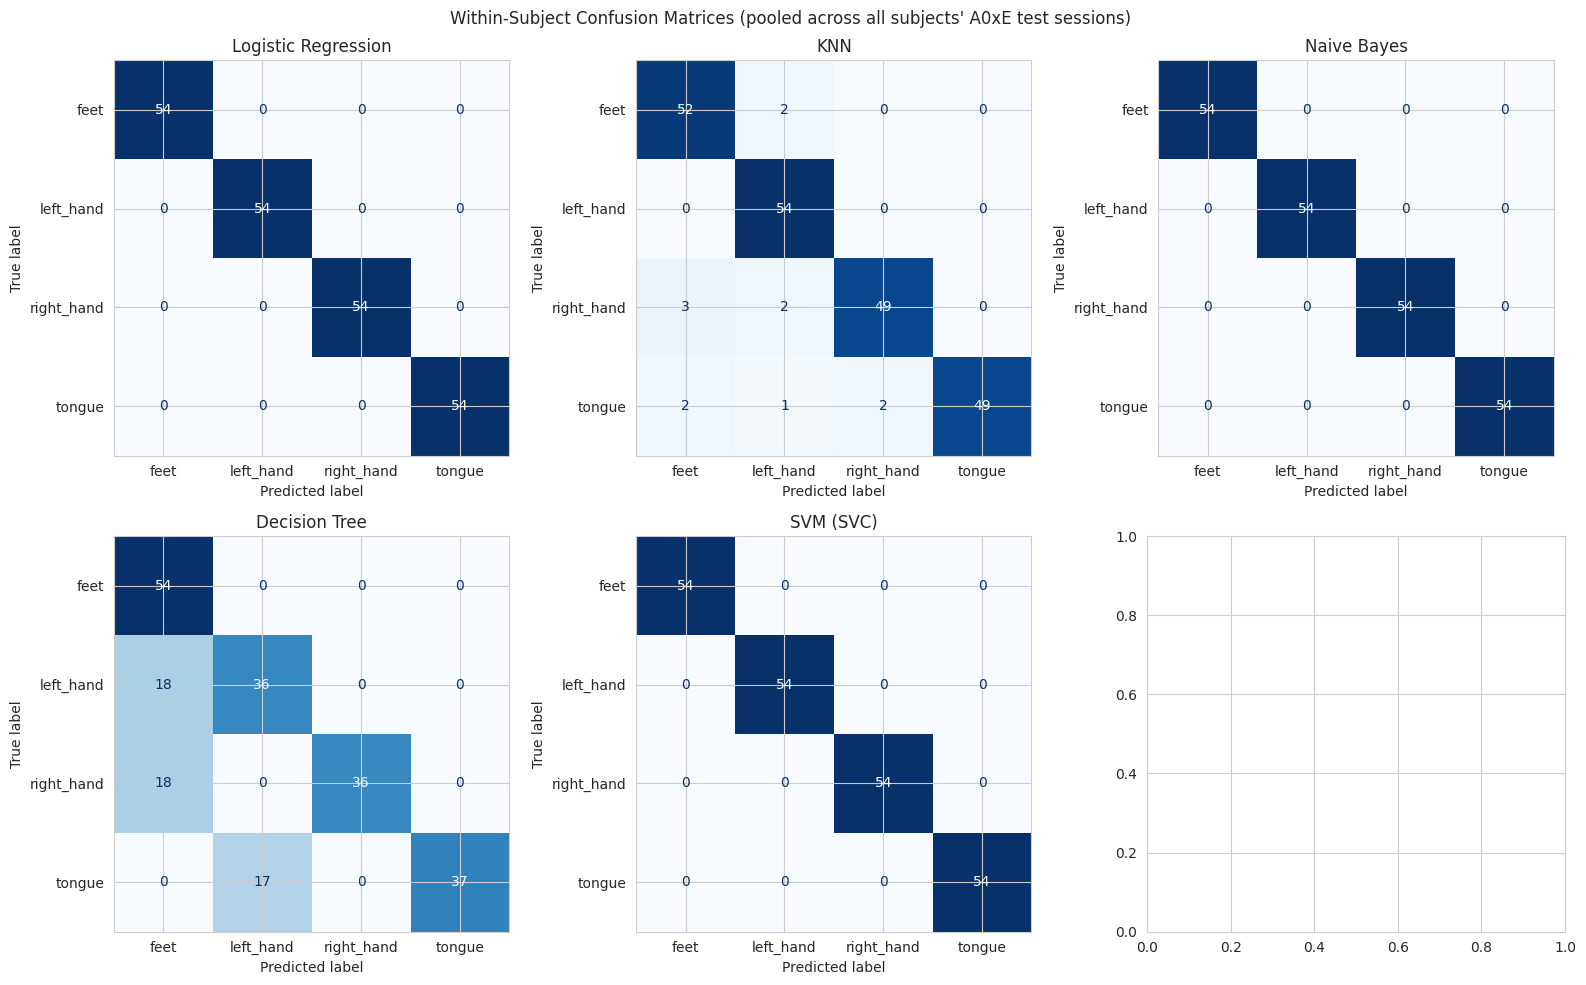

--- Logistic Regression (within-subject, pooled) ---
              precision    recall  f1-score   support

        feet       1.00      1.00      1.00        54
   left_hand       1.00      1.00      1.00        54
  right_hand       1.00      1.00      1.00        54
      tongue       1.00      1.00      1.00        54

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216

--- KNN (within-subject, pooled) ---
              precision    recall  f1-score   support

        feet       0.91      0.96      0.94        54
   left_hand       0.92      1.00      0.96        54
  right_hand       0.96      0.91      0.93        54
      tongue       1.00      0.91      0.95        54

    accuracy                           0.94       216
   macro avg       0.95      0.94      0.94       216
weighted avg       0.95      0.94      0.94       216

--- Naive Bayes (within-subject, pooled)

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat
for ax, (name, preds) in zip(axes, within_subject_preds.items()):
    cm = confusion_matrix(preds["y_true"], preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_ref.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
for ax in list(axes)[len(within_subject_preds):]:
    ax.axis("off")
fig.suptitle("Within-Subject Confusion Matrices (pooled across all subjects' A0xE test sessions)")
plt.tight_layout()
plt.show()

for name, preds in within_subject_preds.items():
    print(f"--- {name} (within-subject, pooled) ---")
    print(classification_report(preds["y_true"], preds["y_pred"], target_names=le_ref.classes_, zero_division=0))

## 9.2 Within-Subject vs Cross-Subject Comparison Table

In [29]:
comparison = within_summary[["Accuracy_mean", "F1 (weighted)_mean"]].rename(
    columns={"Accuracy_mean": "Within-Subject Accuracy", "F1 (weighted)_mean": "Within-Subject F1"}
).join(
    cross_summary[["Accuracy_mean", "F1 (weighted)_mean"]].rename(
        columns={"Accuracy_mean": "Cross-Subject Accuracy", "F1 (weighted)_mean": "Cross-Subject F1"}
    )
).sort_values("Within-Subject F1", ascending=False)

comparison

,Within-Subject Accuracy,Within-Subject F1,Cross-Subject Accuracy,Cross-Subject F1
Model,,,,
Logistic Regression,1.000,1.000,1.00,1.000
SVM (SVC),1.000,1.000,1.00,1.000
Naive Bayes,1.000,1.000,1.00,1.000
KNN,0.944,0.943,0.69,0.684
Decision Tree,0.755,0.717,1.00,1.000


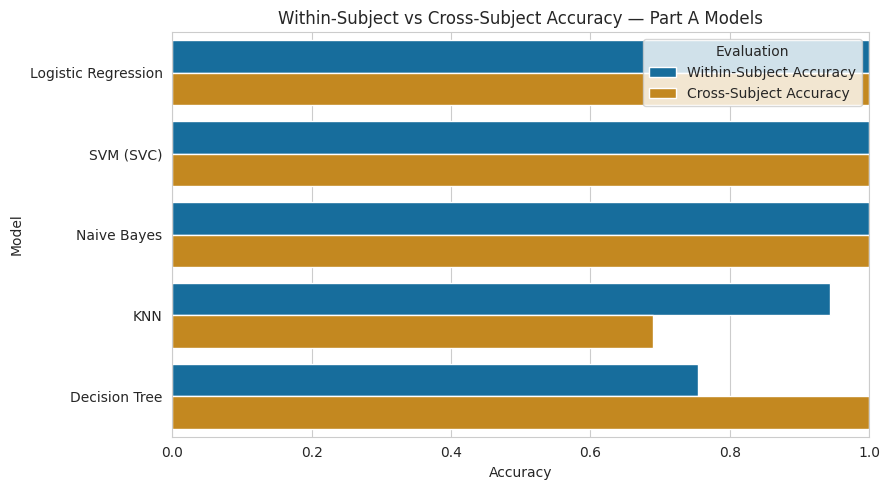

In [30]:
plot_df = comparison.reset_index().melt(id_vars="Model",
                                          value_vars=["Within-Subject Accuracy", "Cross-Subject Accuracy"],
                                          var_name="Evaluation", value_name="Accuracy")
plt.figure(figsize=(9, 5))
sns.barplot(x="Accuracy", y="Model", hue="Evaluation", data=plot_df, palette="colorblind")
plt.title("Within-Subject vs Cross-Subject Accuracy — Part A Models")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---